# Projet Machine Learning

Ce deuxième notebook se concentre sur la prédiction en Python des variables *Heart_Disease_Risk* et *Cholesterol_LDL*. Pour garder une logique commune dans tout notre projet, nous avons utilisé exactement le même nettoyage de données que dans notre notebook réalisé sous R  dans la partie **analyse exploratoire des données**. Comme les choix de préparation sont identiques, nous ne les expliquerons pas à nouveau ici ; vous pouvez retrouver tous les détails dans l'autre notebook.

## Librairie utilisées


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Récupération des données

In [3]:
data = pd.read_csv('healthcare_synthetic_data.csv')

## Modification des données

In [4]:
data["SBMI"] = np.sqrt(data["BMI"])
data["SWeight"] = np.sqrt(data["Weight_kg"])
data["S_Fasting_Blood_Sugar"] = np.sqrt(data["Fasting_Blood_Sugar"])
data["L_Height_cm"] = np.log(data["Height_cm"])


if 'Patient_ID' in data.columns:
    data = data.drop(columns=['Patient_ID'])
#on supprime les anciennes variables qui ont été transformés
data=data.drop(columns=['BMI',"Weight_kg","Fasting_Blood_Sugar","Height_cm","Heart_Disease_Risk"])



cat_vars = [
    "Gender", "Smoking_Status", "Family_History", "Alcohol_Consumption", 
    "Physical_Activity_Level", "Stress_Level", "Sleep_Hours"
]

for var in cat_vars:
    data[var] = data[var].astype('category')


In [5]:

print("\n--- Statistiques descriptives (quantitatives) ---")
print(data.describe())

print("\n--- Statistiques descriptives (qualitatives) ---")
print(data.describe(include=['category']))


--- Statistiques descriptives (quantitatives) ---
                Age   Systolic_BP  Diastolic_BP  Cholesterol_Total  \
count  15000.000000  15000.000000  15000.000000       15000.000000   
mean      54.538133    135.117667     90.541267         216.248000   
std       11.875294     11.260634      8.443095          22.692222   
min       25.000000     90.000000     60.000000         127.000000   
25%       46.000000    127.000000     85.000000         201.000000   
50%       55.000000    135.000000     91.000000         216.000000   
75%       63.000000    143.000000     96.000000         231.000000   
max       85.000000    182.000000    120.000000         303.000000   

       Cholesterol_LDL  Cholesterol_HDL          SBMI       SWeight  \
count     15000.000000     15000.000000  15000.000000  15000.000000   
mean        140.355267        43.307867      5.224238      8.637448   
std          17.914089         5.963153      0.391701      0.804429   
min          70.000000        20.0

## Etude Cholesterol LDL

Avant de passer à la prédiction du taux de cholestérol LDL, nous commençons par une analyse uni et bidimensionnelle de cette variable. Cette première partie nous permet de mieux comprendre la distribution des données et les relations entre les variables.

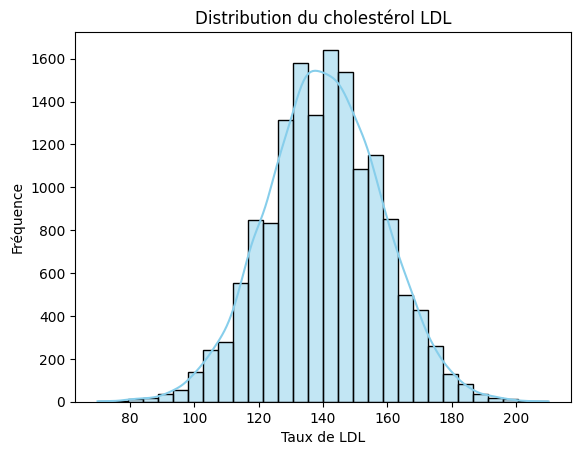

In [6]:

sns.histplot(data['Cholesterol_LDL'], bins=30, kde=True, color='skyblue')
plt.title('Distribution du cholestérol LDL')
plt.xlabel('Taux de LDL')
plt.ylabel('Fréquence')
plt.show()

L'histogramme montre que le taux de cholestérol LDL suit une loi normale, avec une forme en cloche bien symétrique centrée autour de 140. Cette répartition équilibrée indique qu'il y a peu de valeurs extrêmes et que les données sont bien distribuées. C'est un excellent point pour nos modèles de régression, car cela facilite l'apprentissage et permet d'obtenir des prédictions plus stables sans avoir à transformer la variable.

La cellule suivante présente la matrice de corrélation entre les variables quantitatives du jeu de données. Ce graphique nous permet d'identifier rapidement les variables les plus liées au taux de cholestérol LDL.

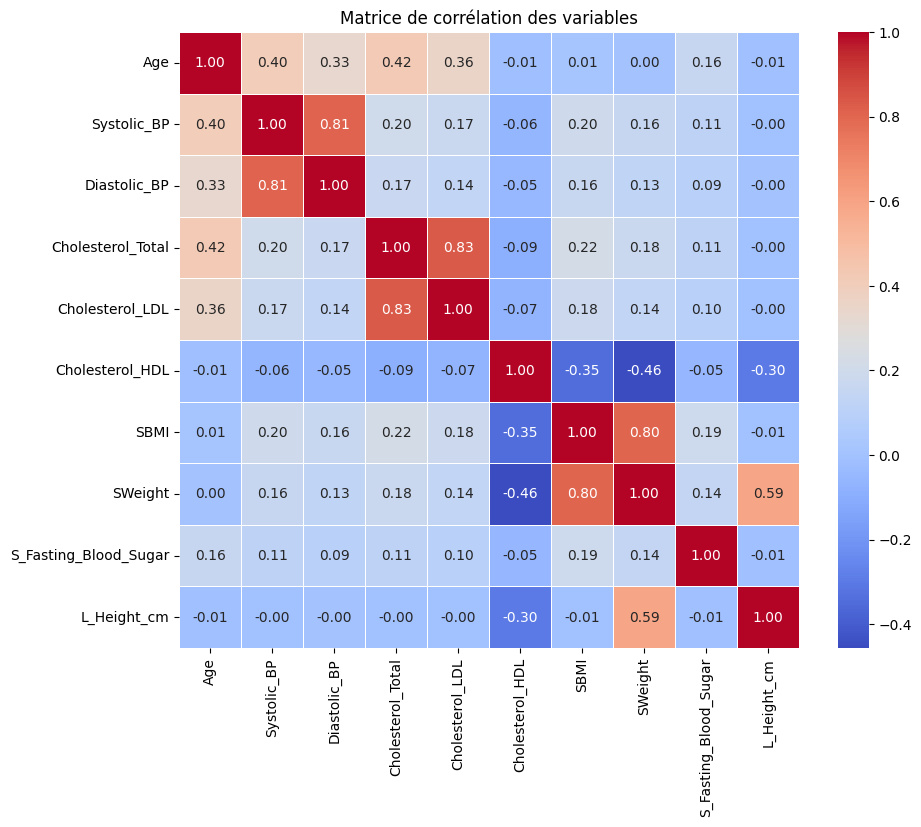

In [7]:
#on séléctionne uniquement les variables quantitatives
corr_matrix = data.select_dtypes(include=['number']).corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice de corrélation des variables')
plt.show()

La matrice de corrélation montre que le taux de cholestérol LDL est très fortement lié au Cholesterol_Total ($0.83$), ce qui est logiquement attendu puisque le LDL en est une composante majeure. On observe également une corrélation modérée avec l'âge ($0.36$), suggérant que le taux de LDL tend à augmenter avec les années. En revanche, il n'existe pratiquement aucune relation linéaire avec le cholestérol HDL ou les autres mesures physiques comme le poids ou la taille.

## Division du jeu de données 

Nous commençons par diviser notre jeu de données en ensembles d'entraînement et de test, puis nous les normalisons. Cette étape de préparation est essentielle pour garantir que nos modèles apprennent sur des données cohérentes et pour évaluer leurs performances de manière fiable.

In [8]:
from sklearn.model_selection import train_test_split 
Y=data["Cholesterol_LDL"]
X = data.drop(columns=['Cholesterol_LDL'])
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=11)


In [9]:
from sklearn.preprocessing import StandardScaler  

scaler = StandardScaler()  
scaler.fit(X_train)  
X_train = scaler.transform(X_train)  
# Meme transformation sur le test
X_test = scaler.transform(X_test)

Maintenant que nos deux datasets sont prêts nous pouvons passer à notre premier modèle prédictif.

## Régression linéaire avec régularisation Lasso

Nous débutons notre étude par une régression linéaire avec pénalisation Lasso pour effectuer une sélection de variables. Pour optimiser le modèle, nous utilisons la fonction GridSearchCV basée sur la validation croisée. Les valeurs du paramètre alpha ont été choisies précisément autour de 0.13, valeur optimale que nous avions préalablement identifiée grâce à la fonction LassoCV.

In [10]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

In [16]:
# grille de valeurs du paramètre alpha à optimiser
param=[{"alpha":[0.05,0.06,0.08,0.09,0.1,0.11,0.12,0.13,0.14,0.15,0.16]}]
regLasso = GridSearchCV(linear_model.Lasso(), param,cv=10,n_jobs=-1)

regLassOpt=regLasso.fit(X_train, Y_train)
best_predict=regLassOpt.predict(X_test)

print("Meilleur R2 = %f, Meilleur paramètre = %s" % (regLassOpt.best_score_,regLassOpt.best_params_))
print("MSE=",mean_squared_error(best_predict,Y_test))

Meilleur R2 = 0.690792, Meilleur paramètre = {'alpha': 0.13}
MSE= 102.95067235121216


Le meilleur paramètre est lorsque $alpha=0.13$. On obtient donc les coefficients suivants pour notre régression.

In [ ]:
meilleur_modele = regLassOpt.best_estimator_

coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': meilleur_modele.coef_
})
print(coefficients.sort_values(by='Coefficient', ascending=False))

                   Variable  Coefficient
4         Cholesterol_Total    14.765059
0                       Age     0.088109
2               Systolic_BP     0.027934
1                    Gender    -0.000000
3              Diastolic_BP    -0.000000
5           Cholesterol_HDL     0.000000
6            Smoking_Status     0.000000
7       Alcohol_Consumption    -0.000000
8   Physical_Activity_Level    -0.000000
9            Family_History    -0.000000
10             Stress_Level     0.000000
11              Sleep_Hours    -0.000000
12                     SBMI    -0.000000
14    S_Fasting_Blood_Sugar    -0.000000
15              L_Height_cm    -0.000000
13                  SWeight    -0.013257


On peut voir que d'après les coefficients de ce modèle lineaire avec pénalisation Lasso, c'est la quantité de cholestérol totale, l'âge, la pression artérielle systolique et la variable lié au poids (*Sweigth*) qui influencent la prédiction de la quantité du mauvais cholestérol (LDL). En effet, la sélection de variables a annulé 12 des 16 variables initiales pour ne garder que celle précédemment citées. On note que le poids a une influence négative très légère, tandis que les autres variables citées agissent positivement sur le taux de LDL prédit. Pour évaluer la précision de ces résultats, nous allons maintenant confronter visuellement nos prédictions aux valeurs réelles.

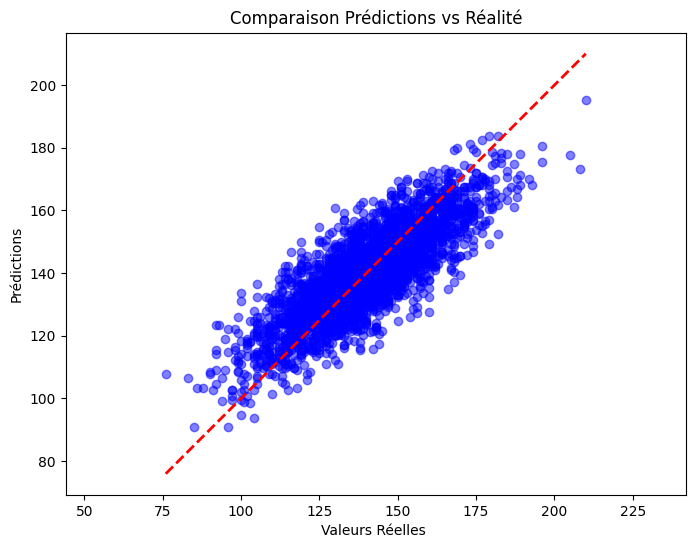

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_test,best_predict, alpha=0.5, color='blue')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel('Valeurs Réelles ')
plt.ylabel('Prédictions')
plt.title('Comparaison Prédictions vs Réalité')
plt.axis('equal')
plt.show()

 Le graphique montre une forte corrélation entre les valeurs réelles et les prédictions, le nuage de points suivant fidèlement la droite $y=x$, ce qui confirme la pertinence du modèle Lasso. On observe toutefois une légère tendance à la sous-estimation pour les valeurs de LDL les plus élevées (au-delà de 180), suggérant que le modèle est extrêmement fiable pour la majorité des patients mais perd un peu en précision sur les cas de cholestérol très sévère. Cette observation montre que les variables sélectionnées capturent bien la tendance générale, même si les valeurs extrêmes restent plus difficiles à prédire parfaitement

### Graphe des résidus

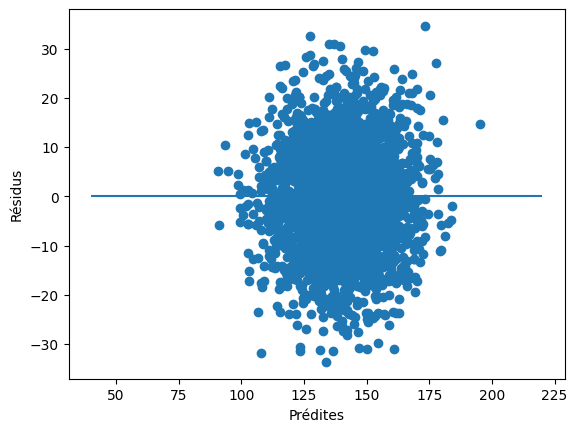

In [40]:
plt.plot(best_predict,Y_test-best_predict,"o")
plt.xlabel(u"Prédites")
plt.ylabel(u"Résidus")
plt.hlines(0,40,220)
plt.show()

Le graphique des résidus montre un nuage de points dispersé de manière aléatoire autour de zéro, sans forme particulière comme une "banane" ou une "trompette". Cette absence de structure valide l'hypothèse d'homoscédasticité, ce qui signifie que l'erreur du modèle est constante et ne dépend pas de la valeur prédite. Cette conclusion confirme la robustesse et la fiabilité de notre régression Lasso pour l'ensemble des données. Enfin nous étudions la MAE qui calcule l'écart moyen entre la prédiction et la valeur réelle.

In [14]:
from sklearn.metrics import mean_absolute_error

In [ ]:
mae = mean_absolute_error(Y_test, best_predict)
print(f"Erreur moyenne (MAE) : ",mae)

Erreur moyenne (MAE) :  8.048362284300906


Ici, la MAE est de $8.05$, ainsi cela signifie que les prédictions du taux de cholestérol LDL s'écartent en moyenne de plus ou moins $8.05$ unités des valeurs réelles observées sur le groupe de test. Enfin, nous traçons le chemin de régularisation pour visualiser comment les coefficients des variables s'annulent à mesure que la pénalité augmente, confirmant ainsi l'impact de notre alpha optimal de 0.13 sur la sélection finale.

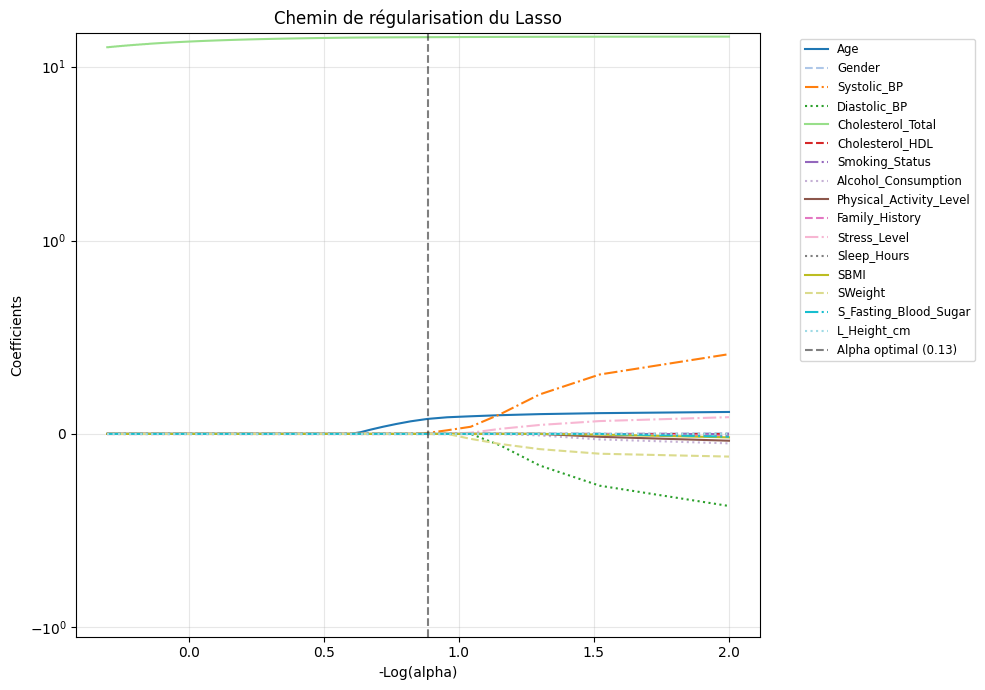

In [23]:
from itertools import cycle
from sklearn.linear_model import lasso_path

#echantillon d'alpha à tester
alphas_lasso, coefs_lasso, _ = lasso_path(X_train, Y_train, alphas=np.linspace(0.01, 2, 100))

plt.figure(figsize=(10, 7))
styles = cycle(['-', '--', '-.', ':'])

colors = plt.cm.tab20(np.linspace(0, 1, X_train.shape[1]))

neg_log_alphas_lasso = -np.log10(alphas_lasso)


for i in range(len(coefs_lasso)):
    plt.plot(neg_log_alphas_lasso, coefs_lasso[i], 
             label=X.columns[i],
             linestyle=next(styles), 
             color=colors[i])

alpha_opt = 0.13
plt.axvline(-np.log10(alpha_opt), linestyle='--', color='k', alpha=0.5, label=f'Alpha optimal ({alpha_opt})')
plt.yscale('symlog', linthresh=1)
plt.xlabel('-Log(alpha)')
plt.ylabel('Coefficients')
plt.title('Chemin de régularisation du Lasso')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small') # Légende à l'extérieur
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

On retrouve bien ce qu'on a vu précédemment le coefficients lié au cholesterol total est nettement plus grand que les autre qui sont proche de 0.

Nous allons passer au prochain algoritme qui est une **SVR**.

## SVR

### Kernel linéaire

Nous passons maintenant à la SVR (Support Vector Regression) pour modéliser notre variable quantitative. Comme pour la régression Lasso, nous optimisons les paramètres par validation croisée. Nous avons choisi un noyau linéaire (kernel linear) pour cette première étape, ce qui nous permettra de comparer directement les coefficients obtenus avec ceux de notre modèle précédent.

In [29]:
from sklearn.svm import SVR


param_svr_lin = [
    {
        'kernel': ['linear'], 
        'C': [0.45,0.5,0.55,0.56,0.57,0.6],
        'epsilon': [0.01, 0.1, 0.5]
    }
]


grid_svr_lin = GridSearchCV(SVR(), param_svr_lin, cv=5, n_jobs=-1, scoring='r2')
SVRopt=grid_svr_lin.fit(X_train, Y_train)

print(f"Meilleur C : {grid_svr_lin.best_params_['C']}")
print(f"Meilleur R2 en validation croisée : {grid_svr_lin.best_score_:.4f}")

Meilleur C : 0.55
Meilleur R2 en validation croisée : 0.6900


In [30]:
predict_SVR=grid_svr_lin.predict(X_test)
print("MSE=",mean_squared_error(predict_SVR,Y_test), "MAE=", mean_absolute_error(Y_test,predict_SVR))

MSE= 103.29731202790748 MAE= 8.067485078095604


Pour le kernel linéaire, la SVR a une MSE de $103.3$ et une MAE de $8.06$. Regardons donc maintenant les coefficients de cette régression. 

In [31]:
best_svr_lin = grid_svr_lin.best_estimator_

coef_svr = pd.DataFrame({
    'Variable': X.columns, 
    'Coefficient': best_svr_lin.coef_[0]  # [0] car coef_ est une matrice 2D ici
})

# 3. Tri pour voir les variables les plus influentes
print(coef_svr.sort_values(by='Coefficient', ascending=False))

                   Variable  Coefficient
4         Cholesterol_Total    14.805933
12                     SBMI     1.385267
15              L_Height_cm     0.947213
2               Systolic_BP     0.526372
11              Sleep_Hours     0.200946
1                    Gender     0.191794
5           Cholesterol_HDL     0.171447
10             Stress_Level     0.106184
9            Family_History     0.052993
6            Smoking_Status     0.051354
0                       Age     0.047921
14    S_Fasting_Blood_Sugar     0.032617
8   Physical_Activity_Level     0.024944
7       Alcohol_Consumption    -0.150313
3              Diastolic_BP    -0.443324
13                  SWeight    -1.706385


On remarque que, tout comme pour la régression Lasso, le cholestérol total reste la variable la plus influente. Cependant, le modèle SVR accorde également une importance significative aux mesures corporelles telles que le poids (*SWeight*), l'IMC (*SBMI*) et la taille (*L_Height_cm*). Contrairement au Lasso qui avait annulé la plupart de ces variables, la SVR les conserve ici avec des coefficients non nuls, ce qui permet d'affiner la prédiction en tenant davantage compte de la morphologie du patient.

Nous allons maintenant tester des noyaux non linéaires, comme les kernels RBF et polynomial, pour voir s'ils surpassent le modèle linéaire. Ces méthodes permettent de capturer des relations plus complexes entre les variables que la simple régression. 

### Autres kernels

In [41]:
param_grid_SVR = [
    {

        'kernel': ['rbf'], 
        'C': [5.8,6,6.2,6.25,6.3], 
        'epsilon': [0.1, 0.05]
    },
    {

        'kernel': ['poly'], 
        'degree': [2,3], 
        'C': [1, 5],
        'epsilon': [0.1]
    }
]
grid_svr_nonlin = GridSearchCV(SVR(), param_grid_SVR, cv=5, scoring='r2', n_jobs=-1)
grid_svr_nonlin.fit(X_train, Y_train)

print(f"Meilleur Kernel : {grid_svr_nonlin.best_params_['kernel']}")
print(f"Paramètres optimaux : {grid_svr_nonlin.best_params_}")
print(f"Nouveau meilleur R2 : {grid_svr_nonlin.best_score_:.4f}")

Meilleur Kernel : rbf
Paramètres optimaux : {'C': 6.2, 'epsilon': 0.1, 'kernel': 'rbf'}
Nouveau meilleur R2 : 0.6637


In [42]:
predict_SVR_rbf=grid_svr_nonlin.predict(X_test)
print("MSE=",mean_squared_error(predict_SVR_rbf,Y_test))
print("MAE=",mean_absolute_error(Y_test, predict_SVR_rbf))

MSE= 112.23399554544746
MAE= 8.42965437343654


On remarque que les autres kernels n'améliorent pas la prédiction ($MSE=112.23$ et $R²=0.6637$) donc on ne va garder que le modèle avec kernel linéaire. Pour terminer, on va juste analyser le graphe des prédictions de la SVR en fonction des valeurs réelles.

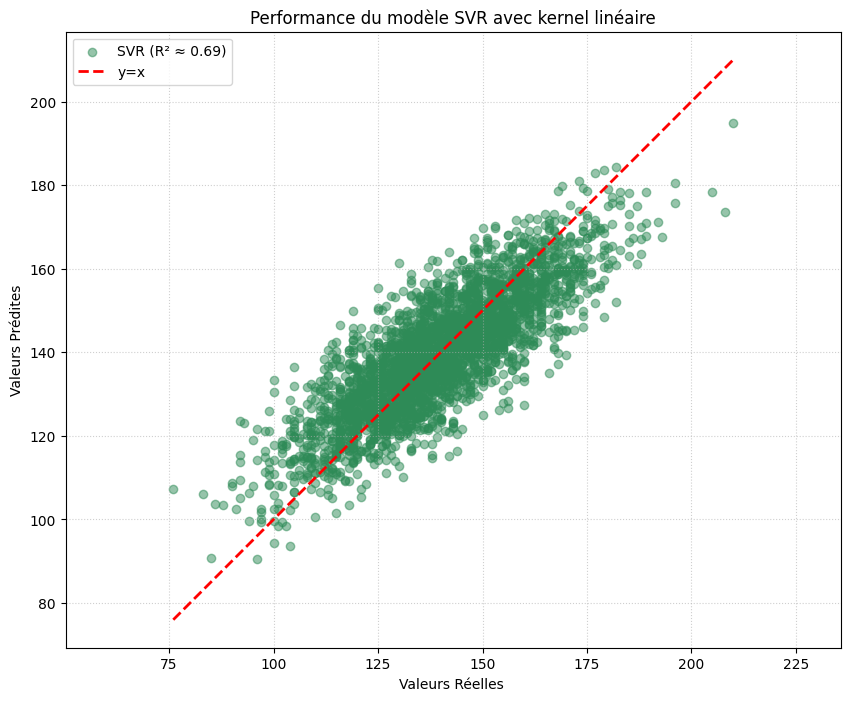

In [44]:
from sklearn.metrics import r2_score

r2_svr = grid_svr_lin.best_score_

# 2. Création du graphique
plt.figure(figsize=(10, 8))

# Affichage des points du SVR
plt.scatter(Y_test, predict_SVR, alpha=0.5, color='seagreen', marker='o', label=f'SVR (R² ≈ {r2_svr:.2f})')

# 3. Ligne de perfection (y = x) pour bien voir l'alignement
lims = [min(Y_test.min(), predict_SVR.min()), max(Y_test.max(), predict_SVR.max())]
plt.plot(lims, lims, 'r--', lw=2, label='y=x')

# 4. Habillage
plt.xlabel('Valeurs Réelles ')
plt.ylabel('Valeurs Prédites')
plt.title('Performance du modèle SVR avec kernel linéaire')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal')

plt.show()

Le graphique montre que les points sont bien regroupés autour de la ligne rouge, ce qui prouve que le modèle SVR fonctionne bien. Il donne des résultats très proches de la régression Lasso. On remarque aussi comme pour Lassoque le modèle a un peu plus de mal à prédire les valeurs très hautes de cholestérol.

Nous avons terminé l'étude des régressions. Nous allons maintenant explorer une autre famille d'algorithmes : les arbres de décision.

## Arbre de décisions

### Random Forest

Nous commençons par l'algorithme des Forêts Aléatoires (Random Forest). Comme précédemment, nous utilisons la validation croisée pour déterminer les paramètres optimaux. Pour le nombre de variables à tester à chaque division (max_features), nous avons comparé trois options : la racine carrée du nombre total de variables, ainsi que le tiers de ce nombre (arrondi à l'entier inférieur et supérieur), afin de trouver le meilleur compromis pour notre modèle

In [40]:
import math

from sklearn.ensemble import RandomForestRegressor 
p= X_train.shape[1] 

p_tiers = math.floor(p/3) 
p_tiers_sup = math.ceil(p/3)


param_grid_rf = {
    'max_features': [p_tiers, p_tiers_sup, 'sqrt'], # On teste p/3 vs les classiques
    'max_depth': [4,5,6,7,8,9, 10,11,12,13,14]
}
rf= GridSearchCV(RandomForestRegressor(n_estimators=200,criterion='squared_error'),
        param_grid_rf,cv=5,n_jobs=-1)
rfOpt=rf.fit(X_train, Y_train)


print("Meilleur score = %f, Meilleur paramètre = %s" % (rfOpt.best_score_,rfOpt.best_params_))

Meilleur score = 0.681219, Meilleur paramètre = {'max_depth': 11, 'max_features': 6}


In [41]:
predict_RF=rfOpt.predict(X_test)
print("MSE=",mean_squared_error(predict_RF,Y_test))
print("MAE=",mean_absolute_error(Y_test, predict_RF))

MSE= 106.077456252806
MAE= 8.165574815169244


Les paramètres optimaux retenus sont une profondeur maximale de 11 et un sous-ensemble de 6 variables par division. Avec ces réglages, le modèle obtient une MSE de $106.51$ et une MAE de $8.17$. Nous allons maintenant analyser l'importance relative de chaque variable au sein de notre Forêt Aléatoire. Cela nous premettra de vérifier si le modèle s'appuie sur les mêmes variables clés que nos méthodes précédentes (Lasso et SVR).

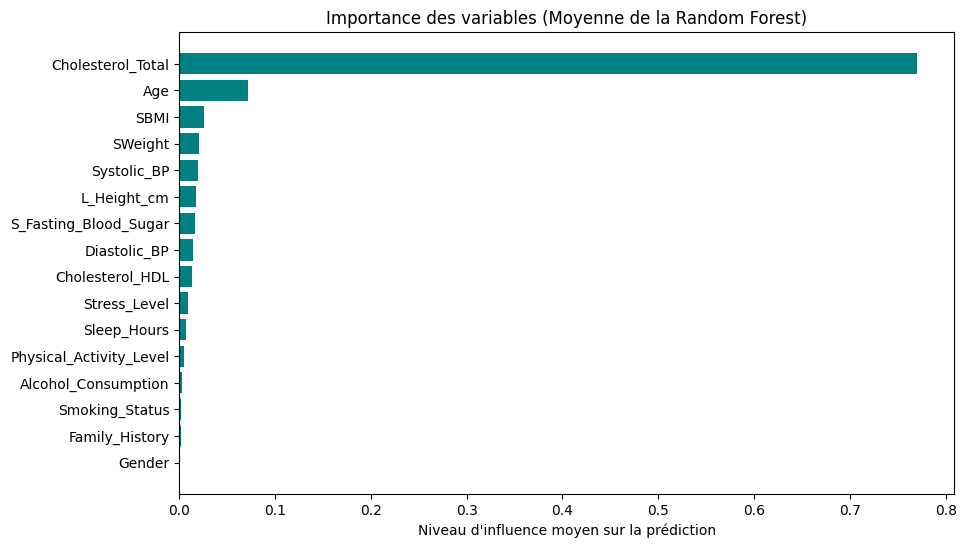

In [42]:
importances = rfOpt.best_estimator_.feature_importances_
labels = X.columns

df_importance = pd.DataFrame({'Variable': labels, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_importance['Variable'], df_importance['Importance'], color='teal')
plt.xlabel("Niveau d'influence moyen sur la prédiction")
plt.title("Importance des variables (Moyenne de la Random Forest)")
plt.show()

A nouveau, c'est le cholestérol total domine largement les prédictions, suivi de loin par l'âge et les indicateurs corporels (*SBMI*, *SWeight*). Cela confirme les résultats de nos modèles précédents : les facteurs biologiques sont nettement plus influent que le mode de vie (stress, sommeil, alcool) pour expliquer le taux de LDL.

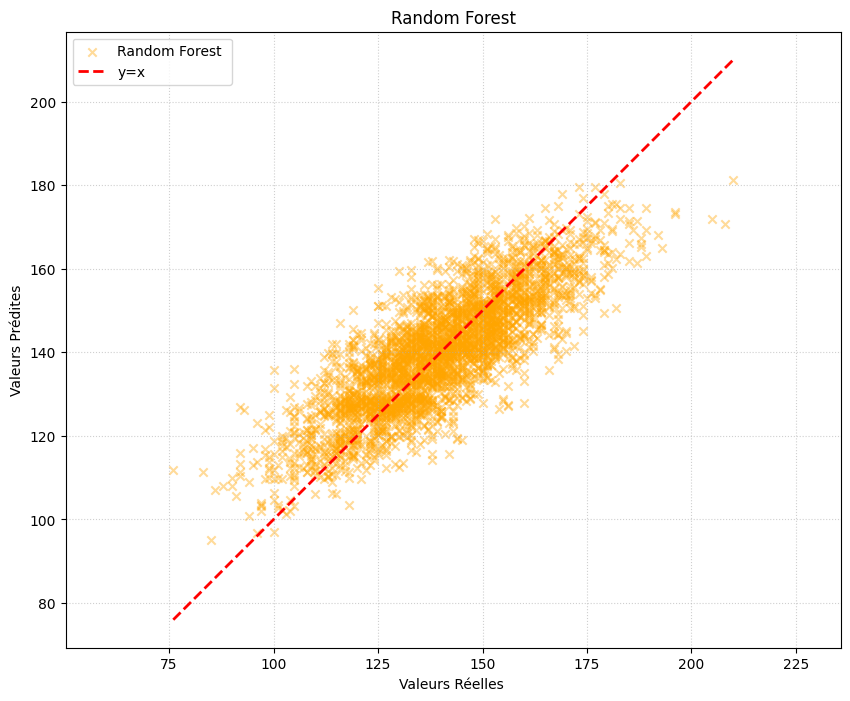

In [43]:
plt.figure(figsize=(10, 8))
plt.scatter(Y_test,predict_RF, alpha=0.4, color='orange', marker='x', label=f'Random Forest ')

lims = [min(Y_test.min(), predict_RF.min()), max(Y_test.max(), predict_RF.max())]
plt.plot(lims, lims, 'r--', lw=2, label='y=x')

plt.xlabel('Valeurs Réelles ')
plt.ylabel('Valeurs Prédites')
plt.title('Random Forest')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal')

plt.show()

Puisque les écarts de prédictions entre les modèles sont que légèrement différent on retrouve encore une fois la même conclusion sur lle graphe des valeurs prédites en fonctions des valeurs réelles. C'est à dire que de manière globale la recontruction est bonne mais pour le valeur plus grande de "mauvais cholestérol", la prédiction est moins bonne. 

Le prochain algorithme de cette famille est l'arbre de décision **CART** (Classification and Regression Trees).

## CART

Nous étudions à présent l'arbre de décision CART. Théoriquement, ce modèle devrait être moins performant que la Forêt Aléatoire, car il ne s'appuie que sur un seul arbre au lieu de faire la moyenne de plusieurs centaines pour stabiliser les prédictions. Cette étape nous permettra de voir si un modèle plus simple et plus lisible suffit à obtenir une précision satisfaisante.

In [52]:
from sklearn.tree import DecisionTreeRegressor

param_cart = {
    'max_depth': [3,4, 5,6, 7, 10],
    'min_samples_leaf': [2,3,4,5,6,7,8,9,10],
    'criterion': ['squared_error', 'friedman_mse']
}


grid_cart = GridSearchCV(DecisionTreeRegressor(random_state=11), 
                         param_cart, cv=5, scoring='r2', n_jobs=-1)
cart_opt = grid_cart.fit(X_train, Y_train)

# 3. Prédictions et Scores
predict_cart = cart_opt.predict(X_test)

print(f"Meilleurs paramètres CART : {cart_opt.best_params_}")
print(f"R² CART : {r2_score(Y_test, predict_cart):.4f}")

Meilleurs paramètres CART : {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 9}
R² CART : 0.6701


In [54]:

print("MSE=",mean_squared_error(predict_cart,Y_test))
print("MAE=",mean_absolute_error(Y_test, predict_cart))

MSE= 104.91868857071766
MAE= 8.116990874278239


Étonnamment, ce modèle obtient une erreur quadratique moyenne plus faible que la Forêt Aléatoire ($MSE = 104.91$ contre $106.51$). Cependant, le coefficient de détermination ($R²$) reste supérieur pour la Forêt Aléatoire. Cette différence s'explique par le fait que la MSE est très sensible aux erreurs importantes, tandis que le $R²$ évalue mieux la capacité globale du modèle à expliquer la variance totale des données.

In [17]:
from sklearn import tree

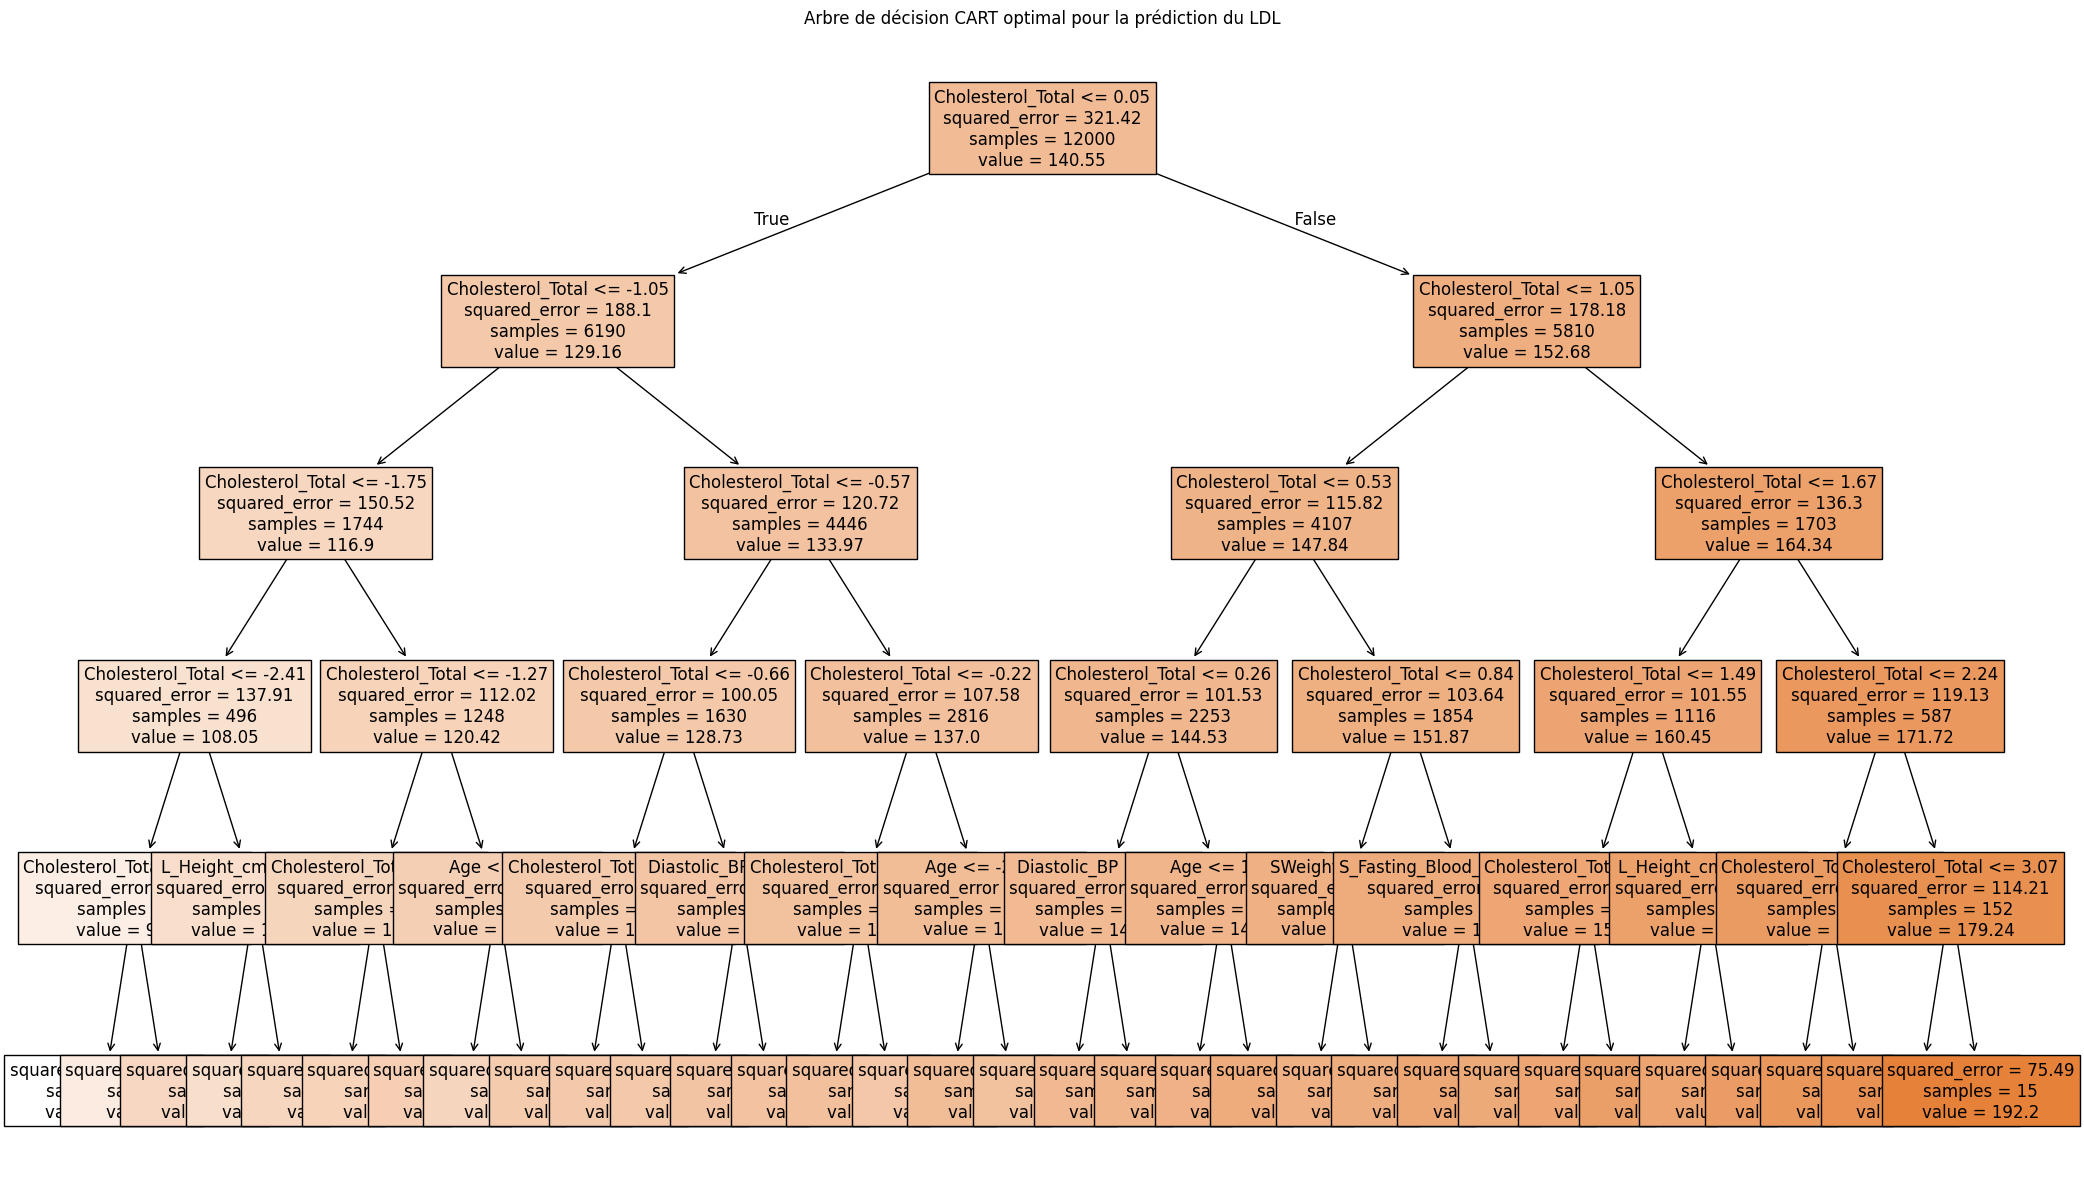

In [ ]:
plt.figure(figsize=(25, 15))
tree.plot_tree(cart_opt.best_estimator_, 
               feature_names=X.columns, 
               filled=True, 
               fontsize=12,
               precision=2)
plt.title("Arbre de décision CART optimal pour la prédiction du LDL")
plt.show()

La lecture de l'arbre confirme que le cholestérol total constitue le facteur discriminant le plus important, puisqu'il est sélectionné pour la première division à la racine. On observe ensuite les autres facteurs sont l'âge et des variables morphologiques comme le poids ou l'IMC. 

Après avoir étudié les arbres simples et les forêts aléatoires, nous allons maintenant explorer le **Boosting**.

# Boosting

Dans la cellule suivante, nous allons mettre en œuvre un modèle de Gradient Boosting. Comme pour les méthodes précédentes, nous optimisons les hyperparamètres par validation croisée. Les valeurs testées ici ont été choisies empiriquement afin de cibler au mieux la combinaison optimale.

In [32]:
from sklearn.ensemble import GradientBoostingRegressor

param_boost = {
    'learning_rate': [0.02,0.03,0.04,0.05], 
    'max_depth': [2,3, 4, 5,6],
    'subsample': [0.04,0.05,0.6,0.7,0.8],
    'n_estimators': [50, 100, 200],

}

grid_boost = GridSearchCV(GradientBoostingRegressor(random_state=11), 
                          param_boost, cv=5, scoring='r2', n_jobs=-1)
boost_opt = grid_boost.fit(X_train, Y_train)

print(f"Meilleur R² Boosting : {boost_opt.best_score_:.4f}")
print(f"Paramètres : {boost_opt.best_params_}")

Meilleur R² Boosting : 0.6888
Paramètres : {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.6}


In [33]:
from sklearn.metrics import mean_squared_error

predict_boost = boost_opt.predict(X_test)
print("MSE=",mean_squared_error(predict_boost,Y_test))
print("MAE=",mean_absolute_error(Y_test, predict_boost))

MSE= 103.55973717981243
MAE= 8.068706045807506


e modèle optimal retient une profondeur maximale de 2 ($max_depth=2$). On obtient alors un $R^2$ de $0.6888$ et une erreur quadratique moyenne (MSE) de $103.56$. Afin d'obtenir une première représentation visuelle de la structure du modèle, le premier arbre de la forêt de boosting est affiché dans la cellule suivante.

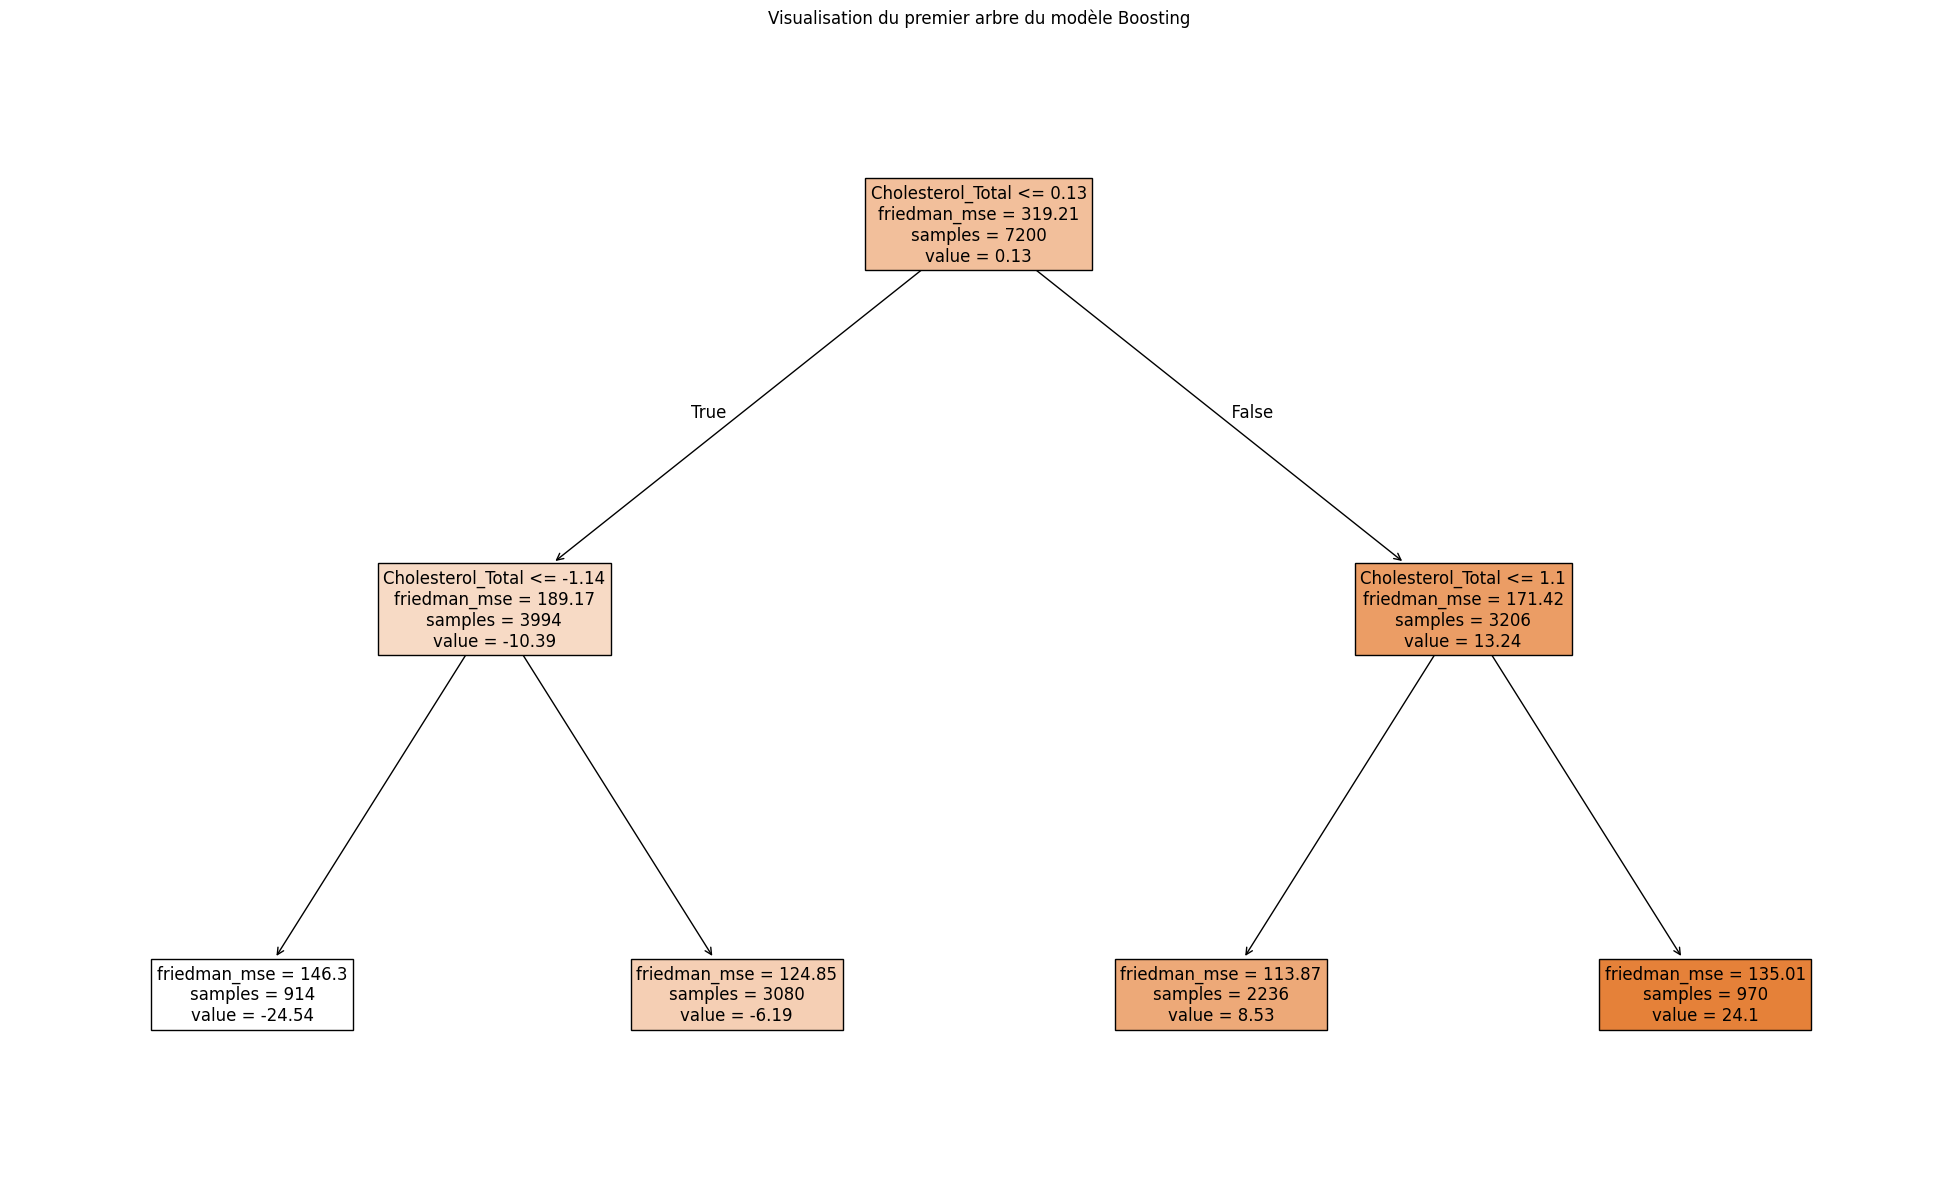

In [34]:
plt.figure(figsize=(25, 15))

# On accède au premier arbre de la forêt de boosting

tree_to_plot = boost_opt.best_estimator_.estimators_[0, 0]

tree.plot_tree(tree_to_plot, 
               feature_names=X.columns, 
               filled=True, 
               fontsize=12,
               precision=2)

plt.title("Visualisation du premier arbre du modèle Boosting")
plt.show()

Ce premier arbre confirme visuellement le choix des hyperparamètres avec une profondeur maximale de 2 (max_depth=2). On constate que le Cholesterol_Total est la seule variable utilisée pour scinder les données à chaque nœud, confirmant son rôle de facteur discriminant majeur.

Les valeurs numériques observées dans les feuilles (allant de $-24.54$ à $+24.10$) ne représentent pas ici le taux de cholestérol LDL final, mais des résidus (ou corrections) que l'algorithme va faire. Fidèle au principe du Gradient Boosting, ce premier arbre applique une première correction positive ou négative à la moyenne globale des patients. Celle-ci sera ensuite affinée par l'action successive et cumulative des 199 arbres suivants, chacun multiplié par le taux d'apprentissage ($learningrate = 0.03$).

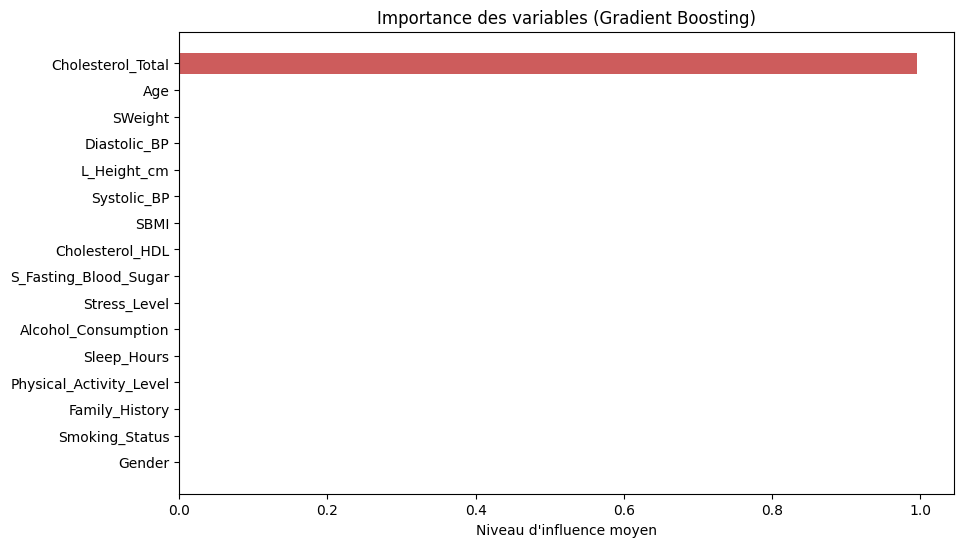

In [35]:
importances_boost = boost_opt.best_estimator_.feature_importances_
df_imp_boost = pd.DataFrame({'Variable': X.columns, 'Importance': importances_boost})
df_imp_boost = df_imp_boost.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_imp_boost['Variable'], df_imp_boost['Importance'], color='indianred')
plt.xlabel("Niveau d'influence moyen")
plt.title("Importance des variables (Gradient Boosting)")
plt.show()

Le graphique de l’importance des variables révèle un comportement très polarisé du **Gradient Boosting**. Contrairement à la Forêt Aléatoire qui distribuait une partie de son attention à l'âge ou aux critères morphologiques (comme le poids), le Boosting concentre la quasi-totalité de son importance (proche de 100 %) sur une seule variable : le *Cholesterol_Total*.

Si le graphique de l'importance des variables met en évidence la structure des décisions du modèle, il est essentiel de s'assurer que cette focalisation extrême sur le cholestérol ne conduit pas à du surapprentissage. C'est ce que permet de vérifier l'analyse de l'évolution de l'erreur afficher dans la cellule suivante.

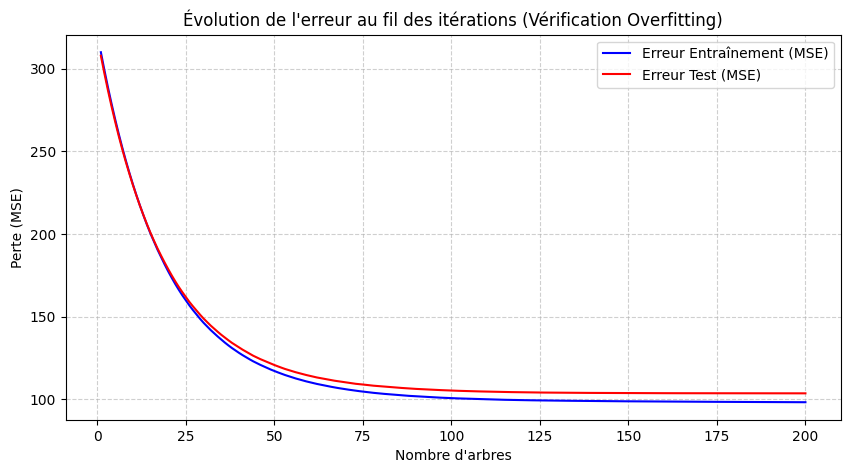

In [36]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1. On récupère le nombre d'arbres final
n_trees = boost_opt.best_estimator_.n_estimators

# 2. On calcule la MSE sur le Test à chaque étape
test_score = np.zeros((n_trees,), dtype=np.float64)
for i, y_pred in enumerate(boost_opt.best_estimator_.staged_predict(X_test)):
    test_score[i] = mean_squared_error(Y_test, y_pred)

# 3. On calcule la MSE sur l'Entraînement à chaque étape
train_score = np.zeros((n_trees,), dtype=np.float64)
for i, y_pred in enumerate(boost_opt.best_estimator_.staged_predict(X_train)):
    train_score[i] = mean_squared_error(Y_train, y_pred)

# 4. Affichage du graphique
plt.figure(figsize=(10, 5))
plt.plot(np.arange(n_trees) + 1, train_score, 'b-', label='Erreur Entraînement (MSE)')
plt.plot(np.arange(n_trees) + 1, test_score, 'r-', label='Erreur Test (MSE)')
plt.ylabel('Perte (MSE)')
plt.xlabel('Nombre d\'arbres')
plt.title('Évolution de l\'erreur au fil des itérations (Vérification Overfitting)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Le graphique d'Évolution de l'erreur confirme l'absence totale de surapprentissage.

Les courbes d'entraînement (bleu) et de test (rouge) diminuent de manière synchrone avant de se stabiliser ensemble à partir de 100 arbres. La courbe de test ne remonte jamais, prouvant une excellente capacité de généralisation.

Ce comportement idéal valide les choix de notre validation croisée : la faible profondeur ($maxdepth=2$) et le sous-échantillonnage ($subsample=0.6$) ont parfaitement régularisé le modèle.

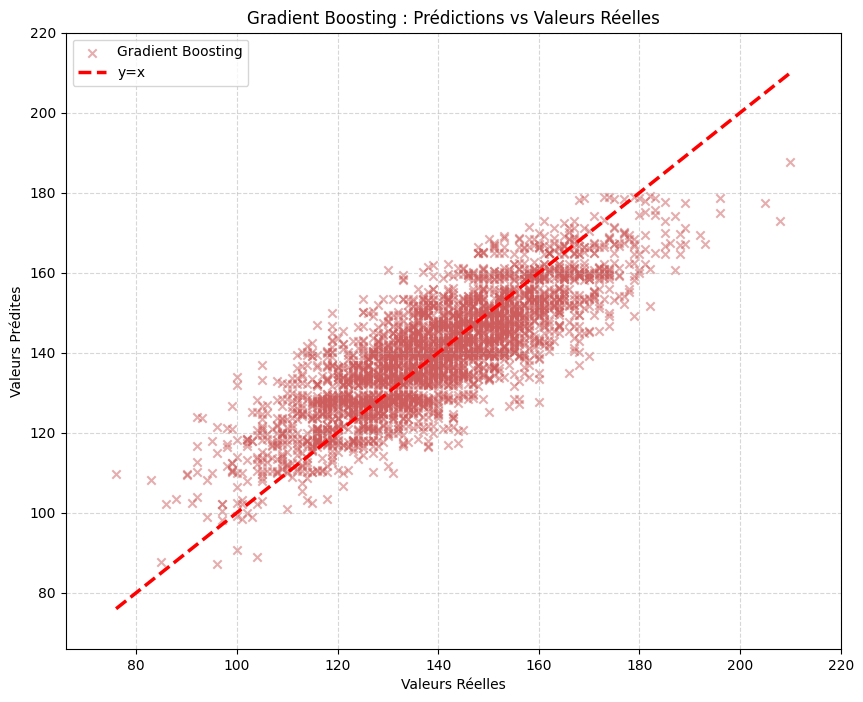

In [39]:

predict_boost = boost_opt.predict(X_test)

# 2. Configuration et tracé du graphique
plt.figure(figsize=(10, 8))

# Nuage de points (on utilise une couleur brique/marron pour changer de la RF)
plt.scatter(Y_test, predict_boost, color='indianred', alpha=0.5, marker='x', label=f"Gradient Boosting")

# Ligne idéale y = x
max_val = max(max(Y_test), max(predict_boost))
min_val = min(min(Y_test), min(predict_boost))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2.5, label='y=x')

# Habillage du graphique
plt.xlabel('Valeurs Réelles')
plt.ylabel('Valeurs Prédites')
plt.title('Gradient Boosting : Prédictions vs Valeurs Réelles')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

# Ajustement des axes pour qu'ils soient lisibles
plt.xlim(min_val - 10, max_val + 10)
plt.ylim(min_val - 10, max_val + 10)

plt.show()

Le graphique confirme que le Gradient Boosting suit la même tendance globale que nos modèles précédents. Bien que le nuage de points soit nettement plus resserré autour de la droite idéale $y=x$, on retrouve le même défaut structurel : le modèle sous-estime systématiquement les valeurs réelles les plus élevées. Dès que le taux réel dépasse $180$, les prédictions sont moins bonnes et sous-estiment la valeur réelle, confirmant la difficulté commune à tous nos algorithmes à modéliser précisément les profils extrêmes.

En conclusion sur les modèles arborescents, le Gradient Boosting s'impose comme le plus performant ($R^2 \approx 0,69$). Néanmoins, tous ces précédentes méthodes partagent la même conclusion: une dépendance exclusive au *Cholestérol total*.

Pour finir nous allons implémenter la dernière methode appartenant à la famille de réseaux de neurones, ce sont les *MLPRegressor*.

# Réseaux de neurones

In [19]:
from sklearn.neural_network import MLPRegressor

In [32]:

param_grid = [{"hidden_layer_sizes": [(5,), (6,), (7,), (8,)]}]

nnet = GridSearchCV(MLPRegressor(max_iter=1000), param_grid, cv=10, n_jobs=-1)

nnetOpt = nnet.fit(X_train, Y_train)

print("Meilleur R² (CV)   = %.4f" % nnetOpt.best_score_)
print("Meilleur paramètre = %s" % nnetOpt.best_params_)


Meilleur R² (CV)   = 0.6884
Meilleur paramètre = {'hidden_layer_sizes': (5,)}


In [ ]:
y_chap = nnetOpt.predict(X_test)

# Calcul de vos métriques habituelles
r2_test = r2_score(Y_test, y_chap)
mse_test = mean_squared_error(Y_test, y_chap)
mae_test = mean_absolute_error(Y_test, y_chap)


print(f"R² (Test)  : {r2_test:.4f}")
print(f"MSE (Test) : {mse_test:.4f}")
print(f"MAE (Test) : {mae_test:.4f}")

=== Évaluation de la Régression ===
R² (Score de précision) : 0.6747
MSE (Erreur moyenne)   : 103.4509
MAE (Erreur absolue)    : 8.0786


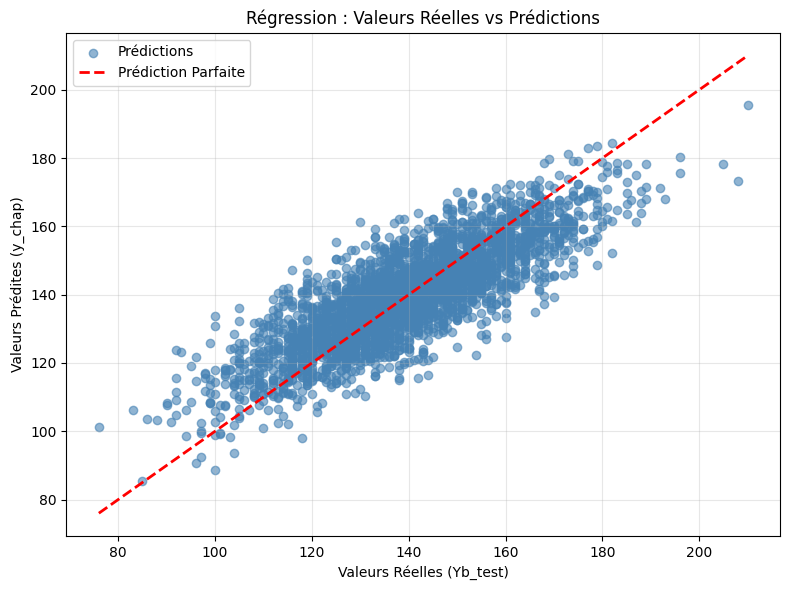

In [ ]:

plt.figure(figsize=(8, 6))

# Nuage de points : Valeurs Réelles vs Prédictions
plt.scatter(Y_test, y_chap, color='steelblue', alpha=0.6, label='Prédictions')

# Ligne de perfection (y = x)
# L'équivalent de la diagonale parfaite d'une matrice de confusion !
min_val = min(Y_test.min(), y_chap.min())
max_val = max(Y_test.max(), y_chap.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Prédiction Parfaite')

plt.title('Régression : Valeurs Réelles vs Prédictions')
plt.xlabel('Valeurs Réelles')
plt.ylabel('Valeurs Prédites ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Comparaison des modèles

Maintenant que nous venons d'entrainer et de tester chaque méthode sur notre jeu de données, nous allons les comparer en prenant comme critères la MSE et le score R².

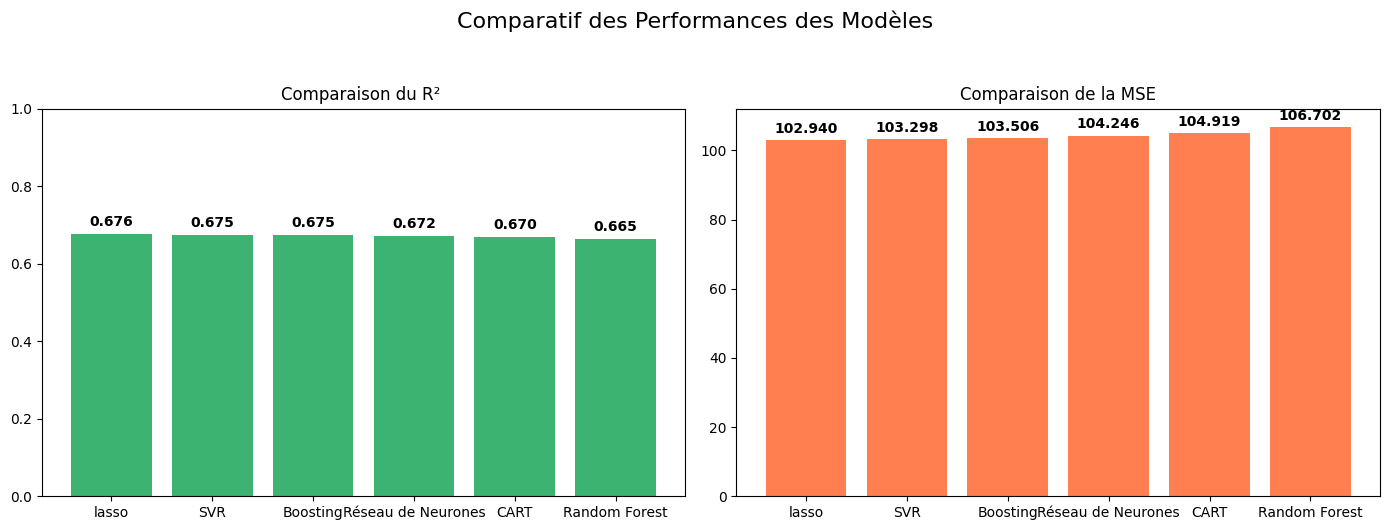

In [71]:
modeles_a_comparer = {
    "Random Forest": rfOpt,
    "Réseau de Neurones": nnetOpt,
     "lasso": regLassOpt,
    "SVR": SVRopt,
    "CART":cart_opt,
    "Boosting":boost_opt
}

scores_r2 = {}
scores_mse = {}
predictions = {}

# 2. Calcul des prédictions et des métriques pour chaque modèle
for nom, modele in modeles_a_comparer.items():
    # Prédiction sur le jeu de test
    y_pred = modele.predict(X_test)
    predictions[nom] = y_pred
    
    # Calcul des métriques
    scores_r2[nom] = r2_score(Y_test, y_pred)
    scores_mse[nom] =mean_squared_error(Y_test, y_pred)


n_modeles = len(modeles_a_comparer)
noms_modeles = list(modeles_a_comparer.keys())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#dictionnaire ordonné du score R² de chaque méthode
r2_tries = dict(sorted(scores_r2.items(), key=lambda item: item[1], reverse=True))
noms_r2 = list(r2_tries.keys())
valeurs_r2 = list(r2_tries.values())

ax1.bar(noms_r2, valeurs_r2, color='mediumseagreen')
ax1.set_title('Comparaison du R² ', fontsize=12)
ax1.set_ylim(0, 1) 
for i, v in enumerate(valeurs_r2):
    ax1.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')


#dictionnaire ordonné du MSE de chaque méthode
mse_tries = dict(sorted(scores_mse.items(), key=lambda item: item[1]))
noms_mse = list(mse_tries.keys())
valeurs_mse = list(mse_tries.values())

ax2.bar(noms_mse, valeurs_mse, color='coral')
ax2.set_title('Comparaison de la MSE', fontsize=12)
for i, v in enumerate(valeurs_mse):
    ax2.text(i, v + (max(valeurs_rmse) * 0.02), f"{v:.3f}", ha='center', fontweight='bold')
plt.suptitle("Comparatif des Performances des Modèles", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

En conclusion, les différentes méthodes testées aboutissent à des performances globales très similaires, sans qu'aucun modèle ne se démarque de façon significative dans ses prédictions. On peut toutefois noter que la régression linéaire avec pénalisation Lasso offre de très légers avantages : elle présente en effet l'erreur quadratique moyenne (MSE) la plus faible de notre étude, couplée au coefficient de détermination (R²) le plus élevé.